# EDA: Collection3 и WikiNEuRal-ru

In [1]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub.utils import logging as hf_logging
from seqeval.metrics.sequence_labeling import get_entities
from transformers import AutoTokenizer

from ru_ner.data import LABELS, load_collection3, load_wikineural_ru

datasets.disable_progress_bars()
hf_logging.set_verbosity_error()
pd.set_option("display.precision", 2)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.axisbelow": True,
    }
)
COLORS = {"c3/train": "#2a78d6", "wikineural/test": "#eb6834"}

In [2]:
c3 = load_collection3()
wn = load_wikineural_ru("test")

corpora = {
    "c3/train": c3["train"],
    "c3/validation": c3["validation"],
    "c3/test": c3["test"],
    "wikineural/test": wn,
}

In [3]:
def entities(ds):
    rows = []
    for i, (tokens, tags) in enumerate(zip(ds["tokens"], ds["ner_tags"], strict=True)):
        for etype, start, end in get_entities([LABELS[t] for t in tags]):
            rows.append(
                {
                    "sent": i,
                    "type": etype,
                    "text": " ".join(tokens[start : end + 1]),
                    "n_tokens": end - start + 1,
                }
            )
    return pd.DataFrame(rows)


ents = {name: entities(ds) for name, ds in corpora.items()}

## Размер корпусов

In [4]:
rows = []
for name, ds in corpora.items():
    e = ents[name]
    counts = e["type"].value_counts()
    rows.append(
        {
            "corpus": name,
            "sentences": len(ds),
            "tokens": sum(len(t) for t in ds["tokens"]),
            "entities": len(e),
            "PER": counts.get("PER", 0),
            "LOC": counts.get("LOC", 0),
            "ORG": counts.get("ORG", 0),
            "no_entities_%": 100 * (1 - e["sent"].nunique() / len(ds)),
        }
    )
pd.DataFrame(rows).set_index("corpus")

,sentences,tokens,entities,PER,LOC,ORG,no_entities_%
corpus,,,,,,,
c3/train,9301,187656,18247,7406,4881,5960,19.51
c3/validation,2153,43856,4117,1641,1168,1308,23.41
c3/test,1922,40260,4001,1570,1175,1256,18.26
wikineural/test,11580,217392,15136,3489,8596,3051,15.76


## Доли типов сущностей

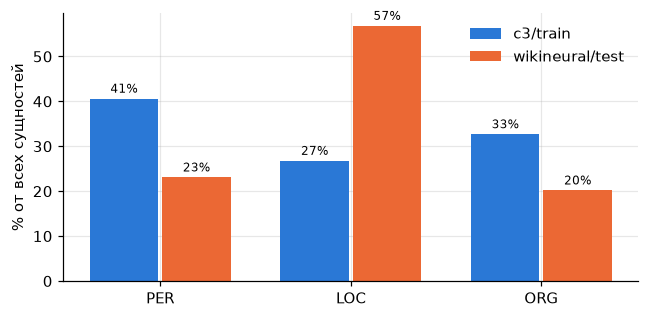

In [5]:
types = ["PER", "LOC", "ORG"]
fig, ax = plt.subplots(figsize=(6, 3))
width = 0.38
x = np.arange(len(types))
for k, name in enumerate(["c3/train", "wikineural/test"]):
    share = ents[name]["type"].value_counts(normalize=True).reindex(types) * 100
    bars = ax.bar(x + (k - 0.5) * width, share, width - 0.02, label=name, color=COLORS[name])
    ax.bar_label(bars, fmt="%.0f%%", fontsize=8, padding=2)
ax.set_xticks(x, types)
ax.set_ylabel("% от всех сущностей")
ax.legend(frameon=False)
plt.tight_layout()

## Длина сущностей в токенах

In [6]:
pd.concat(
    {
        name: ents[name]
        .groupby("type")["n_tokens"]
        .agg(
            mean="mean",
            single_token_pct=lambda s: 100 * (s == 1).mean(),
            max="max",
        )
        for name in ["c3/train", "wikineural/test"]
    }
)

mean  single_token_pct  max
                type                             
c3/train        LOC   1.32             77.61    8
                ORG   2.00             53.81   18
                PER   2.01             27.41   10
wikineural/test LOC   1.11             91.12    7
                ORG   1.66             58.93   13
                PER   1.41             64.83    5

In [7]:
e = ents["c3/train"]
e[e["n_tokens"] >= 6].sort_values("n_tokens", ascending=False).head(8)[["type", "n_tokens", "text"]]

,type,n_tokens,text
13518,ORG,18,Министерства Российской Федерации по делам гра...
17574,ORG,16,Военно - воздушная академия имени Н . Е . Жуко...
6352,ORG,16,Федерального агентства по поставкам вооружения...
2656,ORG,16,Российского национального исследовательского м...
10534,ORG,15,""" Сеть поддержки выборов в Зимбабве "" ( Zimbab..."
11330,ORG,15,Министерства Российской Федерации по делам гра...
11333,ORG,15,Министерства Российской Федерации по делам гра...
10521,ORG,14,""" Африканского национального союза Зимбабве — ..."


## Длина предложений в subword-токенах

Модель видит не слова, а subword-токены. По этой длине выбираем `max_length`.

In [8]:
tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")


def lengths(ds):
    # ds["tokens"] is a lazy Column in datasets 5.x, the tokenizer needs a real list
    tokens = list(ds["tokens"])
    words = np.array([len(t) for t in tokens])
    enc = tokenizer(tokens, is_split_into_words=True)
    subwords = np.array([len(ids) for ids in enc["input_ids"]])
    return words, subwords


len_stats = {}
for name in ["c3/train", "wikineural/test"]:
    words, subwords = lengths(corpora[name])
    len_stats[name] = subwords
    print(
        f"{name:16s} words/sent median={np.median(words):.0f}  "
        f"subwords/word={(subwords - 2).sum() / words.sum():.2f}  "
        f"subwords p50={np.percentile(subwords, 50):.0f} p95={np.percentile(subwords, 95):.0f} "
        f"p99={np.percentile(subwords, 99):.0f} max={subwords.max()}  "
        f">128: {(subwords > 128).mean() * 100:.2f}%  >256: {(subwords > 256).mean() * 100:.2f}%"
    )

c3/train         words/sent median=18  subwords/word=1.09  subwords p50=21 p95=46 p99=65 max=292  >128: 0.08%  >256: 0.01%


wikineural/test  words/sent median=17  subwords/word=1.16  subwords p50=21 p95=47 p99=66 max=178  >128: 0.03%  >256: 0.00%


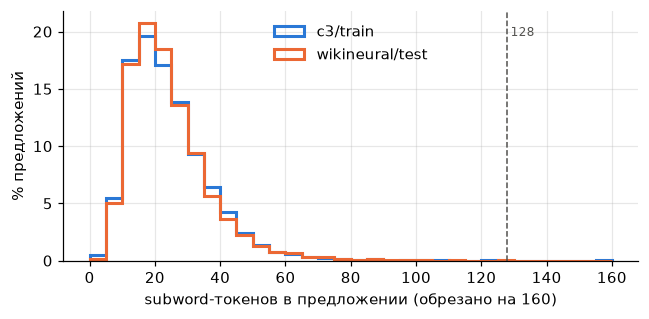

In [9]:
fig, ax = plt.subplots(figsize=(6, 3))
bins = np.arange(0, 161, 5)
for name, subwords in len_stats.items():
    weights = np.full(len(subwords), 100 / len(subwords))
    ax.hist(
        np.clip(subwords, 0, 160),
        bins=bins,
        weights=weights,
        histtype="step",
        linewidth=2,
        label=name,
        color=COLORS[name],
    )
ax.axvline(128, color="#52514e", linestyle="--", linewidth=1)
ax.text(129, ax.get_ylim()[1] * 0.9, "128", fontsize=8, color="#52514e")
ax.set_xlabel("subword-токенов в предложении (обрезано на 160)")
ax.set_ylabel("% предложений")
ax.legend(frameon=False)
plt.tight_layout()

## Пересечение сущностей с train

Какая доля сущностей теста встречалась в train в точности в том же написании.
Высокая доля значит, что метрика частично измеряет запоминание, а не обобщение.

In [10]:
train_ents = ents["c3/train"]
seen = set(zip(train_ents["type"], train_ents["text"], strict=True))

rows = []
for name in ["c3/validation", "c3/test", "wikineural/test"]:
    e = ents[name]
    is_seen = [(t, s) in seen for t, s in zip(e["type"], e["text"], strict=True)]
    e = e.assign(seen=is_seen)
    row = {"corpus": name, "all": 100 * e["seen"].mean()}
    row.update((100 * e.groupby("type")["seen"].mean()).to_dict())
    rows.append(row)
pd.DataFrame(rows).set_index("corpus").round(1)

,all,LOC,ORG,PER
corpus,,,,
c3/validation,60.4,80.7,66.4,41.0
c3/test,58.0,75.9,64.3,39.6
wikineural/test,17.2,27.7,6.1,1.3


## Дубли предложений

Предложения теста, которые дословно есть в train, модель могла просто запомнить.

In [11]:
def sentences(ds):
    return [" ".join(t) for t in ds["tokens"]]


train_sents = set(sentences(corpora["c3/train"]))
rows = []
for name in ["c3/validation", "c3/test", "wikineural/test"]:
    sents = sentences(corpora[name])
    dup = [s for s in sents if s in train_sents]
    rows.append({"corpus": name, "in_train": len(dup), "in_train_%": 100 * len(dup) / len(sents)})
print(f"дублей внутри c3/train: {len(corpora['c3/train']) - len(train_sents)}")
pd.DataFrame(rows).set_index("corpus")

дублей внутри c3/train: 204


,in_train,in_train_%
corpus,,
c3/validation,54,2.51
c3/test,29,1.51
wikineural/test,0,0.00


In [12]:
test_sents = sentences(corpora["c3/test"])
[s for s in test_sents if s in train_sents and len(s.split()) >= 8][:5]

['Указ вступает в силу со дня его подписания .',
 'Заместителем министра финансов РФ в первый раз он был назначен в 2003г . В 2004 - 2005гг . он был директором департамента межбюджетных отношений Минфина .',
 'Все новости экономики и бизнеса на сайте агентства Прайм > >',
 'Об этом сообщила пресс - служба Кремля .',
 'Об этом сообщает пресс - служба Кремля .']

## Некорректные BIO-переходы

In [13]:
def invalid_bio(ds):
    n = 0
    for tags in ds["ner_tags"]:
        prev = "O"
        for t in (LABELS[i] for i in tags):
            if t.startswith("I-") and prev[2:] != t[2:]:
                n += 1
            prev = t
    return n


{name: invalid_bio(ds) for name, ds in corpora.items()}

{'c3/train': 5, 'c3/validation': 0, 'c3/test': 1, 'wikineural/test': 63}

## Примеры

In [14]:
def show(ds, i):
    tokens = list(ds["tokens"][i])
    tags = [LABELS[t] for t in ds["ner_tags"][i]]
    for etype, start, end in reversed(get_entities(tags)):
        tokens[start : end + 1] = [f"[{' '.join(tokens[start : end + 1])}]{etype}"]
    print(" ".join(tokens), end="\n\n")


rng = np.random.default_rng(0)
for name in ["c3/train", "wikineural/test"]:
    print(f"--- {name}")
    for i in rng.choice(len(corpora[name]), 3, replace=False):
        show(corpora[name], int(i))

--- c3/train
Самовыдвиженец , член партии [" Единая Россия "]ORG [Эдгар Петросян]PER заявил об отказе участвовать в предвыборной кампании .

На собрании также были избраны члены ревизионной комиссии .

Вице - президент [Центра политических технологий]ORG [Георгий Чижов]PER довольно скептично оценил вероятность избрания эсэра [Геннадия Гудкова]PER губернатором [Московской области]LOC .

--- wikineural/test
Он помог [Subaru]ORG стать всемирно известной маркой и заработать ей победу в зачёте марок в 1995 , 1996 , 1997 годах , также помог победить команде [Citroën]ORG в 2003-м .

Это не оказывало сильного эффекта на BASIC-программы , но для быстрых программ , написанных на ассемблере , это уже было серьёзным ограничением .

После ряда побед в 1648 году [Тюренн]PER входит в [Мюнхен]LOC , что приводит к заключению Вестфальского мира .



## Выводы

- Collection3: 9.3k предложений в train, 18k сущностей. PER встречается чаще всего,
  около 20% предложений без сущностей.
- WikiNEuRal заметно отличается по составу: LOC 57% сущностей против 27% в Collection3.
  PER в WikiNEuRal в 65% случаев один токен (часто только фамилия), в Collection3 это обычно имя + фамилия.
  Стоит ожидать падения качества при переносе.
- 58% сущностей из c3/test встречались в train в том же написании (LOC 76%, PER 40%).
  Значит, F1 на c3/test частично измеряет запоминание. В WikiNEuRal пересечение 17%, а для PER почти нулевое,
  поэтому это хорошая проверка обобщения. При оценке модели отдельно посчитаю метрики на «новых» сущностях.
- 1.5% предложений c3/test (29 из 1922) дословно есть в train, в основном шаблонные фразы новостных лент.
  Официальный тест не меняю, чтобы можно было сравнивать с опубликованными результатами,
  но дополнительно посчитаю метрики на тесте без этих предложений.
- Разметка WikiNEuRal автоматическая, поэтому F1 на нём показывает согласие с другой моделью,
  а не точное качество. Использую его только как оценку переноса на другой домен.
- 99% предложений короче 66 subword-токенов, длиннее 128 только 0.08%. Беру `max_length=128`.
- ruBERT почти не дробит слова (1.09 subword-токена на слово), так что выравнивание меток
  затронет немного токенов.
- В исходной разметке есть некорректные BIO-переходы: 6 в Collection3 и 63 в WikiNEuRal. Оставляю как есть.
- MISC в WikiNEuRal превращён в O (пример выше: «Вестфальского мира» не размечен),
  поэтому часть ложных срабатываний на WikiNEuRal может оказаться MISC-сущностями.